In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca file Excel
file_path = '3TIC_Kelompok5_RatingAttackOnTitan.xlsx'
df = pd.read_excel(file_path)

# Menampilkan 5 baris pertama data
df.head()

,No.,Season,Episode,Tipe,Judul Episode,Durasi,Tahun Tayang,Rating IMDb
0,1,Season 1,Episode 1,Main,"To You, in 2000 Years: The Fall of Shiganshina...",24,2013,9.2
1,2,Season 1,Episode 2,Main,"That Day: The Fall of Shiganshina, Part 2",24,2013,8.5
2,3,Season 1,Episode 3,Main,"A Dim Light Amid Despair: Humanity's Comeback,...",24,2013,8.1
3,4,Season 1,Episode 4,Main,The Night of the Closing Ceremony: Humanity's ...,24,2013,8.6
4,5,Season 1,Episode 5,Main,"First Battle: The Struggle for Trost, Part 1",24,2013,9.3


In [3]:
# Ringkasan statistik angka (Rating IMDb, Durasi, Tahun Tayang)
print("=== STATISTIK DESKRIPTIF ===")
display(df[['Rating IMDb', 'Durasi', 'Tahun Tayang']].describe())

# Rata-rata rating per Season
print("\n=== RATA-RATA RATING PER SEASON ===")
season_stat = df.groupby('Season')['Rating IMDb'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
display(season_stat)

=== STATISTIK DESKRIPTIF ===


,Rating IMDb,Durasi,Tahun Tayang
count,97.000000,97.000000,97.000000
mean,9.074227,24.020619,2017.525773
std,0.499015,0.142842,3.345061
min,7.600000,24.000000,2013.000000
25%,8.800000,24.000000,2013.000000
50%,9.100000,24.000000,2018.000000
75%,9.500000,24.000000,2021.000000
max,9.800000,25.000000,2023.000000



=== RATA-RATA RATING PER SEASON ===


,Season,count,mean,std,min,max
0,Final Season,30,9.266667,0.402006,8.5,9.8
1,OVA,8,8.487500,0.571808,7.6,9.5
2,Season 1,25,8.820000,0.429146,8.1,9.6
3,Season 2,12,9.100000,0.497265,8.4,9.8
4,Season 3,22,9.300000,0.389138,8.5,9.8


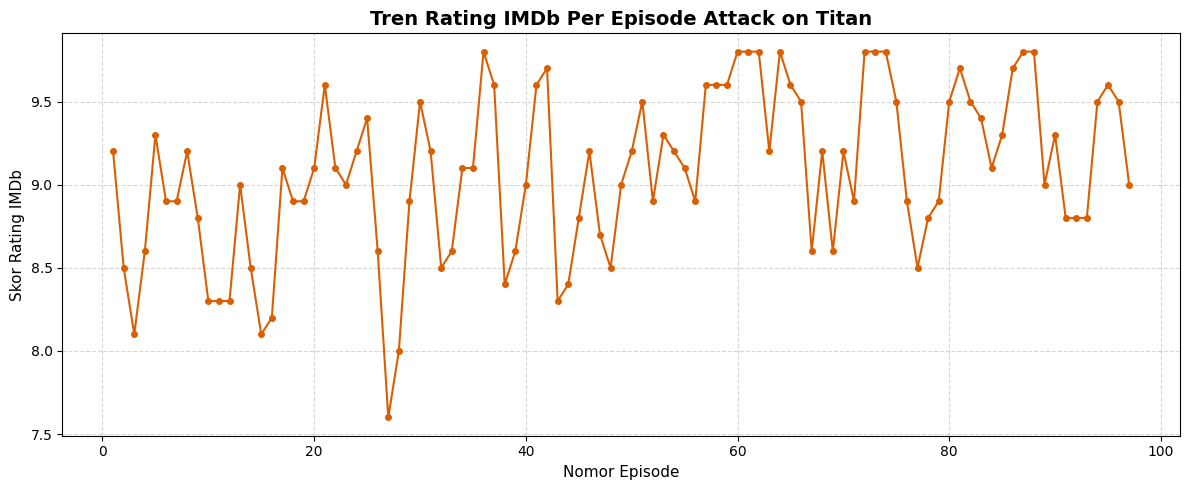

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df['No.'], df['Rating IMDb'], marker='o', color='#d95f02', linewidth=1.5, markersize=4)

plt.title('Tren Rating IMDb Per Episode Attack on Titan', fontsize=14, fontweight='bold')
plt.xlabel('Nomor Episode', fontsize=11)
plt.ylabel('Skor Rating IMDb', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

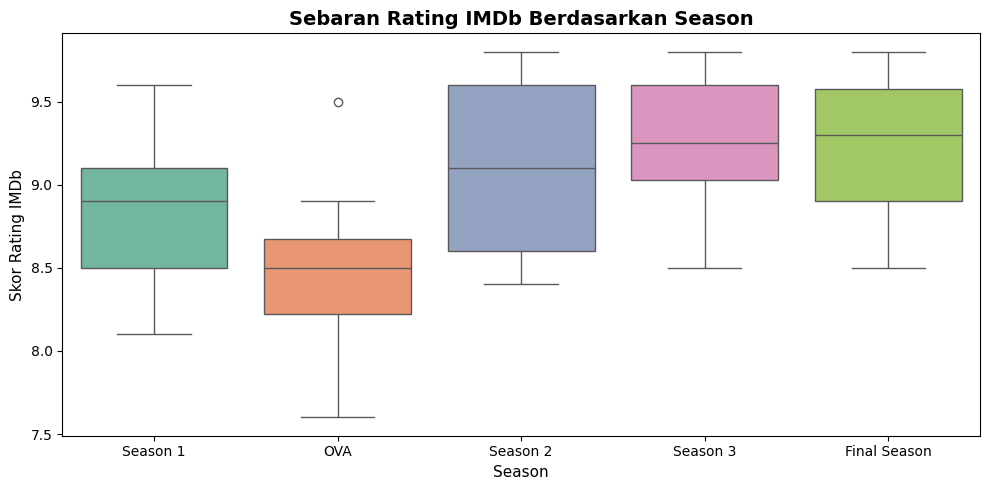

In [10]:
plt.figure(figsize=(10, 5))

# Tambahkan hue='Season' dan legend=False agar warning hilang
sns.boxplot(x='Season', y='Rating IMDb', data=df, palette='Set2', hue='Season', legend=False)

plt.title('Sebaran Rating IMDb Berdasarkan Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=11)
plt.ylabel('Skor Rating IMDb', fontsize=11)

plt.tight_layout()
plt.show()

In [6]:
from scipy import stats

# Filter data
rating_main = df[df['Tipe'] == 'Main']['Rating IMDb']
rating_ova = df[df['Tipe'] == 'OVA']['Rating IMDb']

# Uji-t dua sampel independen
t_stat, p_val = stats.ttest_ind(rating_main, rating_ova)

print("=== UJI BEDA (INDEPENDENT T-TEST): MAIN VS OVA ===")
print(f"Rata-rata Rating Main Episode : {rating_main.mean():.2f}")
print(f"Rata-rata Rating OVA          : {rating_ova.mean():.2f}")
print(f"Nilai t-statistic            : {t_stat:.4f}")
print(f"Nilai p-value                : {p_val:.4f}")

if p_val < 0.05:
    print("Kesimpulan: Terdapat perbedaan rating yang signifikan secara statistik antara episode Main dan OVA.")
else:
    print("Kesimpulan: Tidak terdapat perbedaan rating yang signifikan antara episode Main dan OVA.")

=== UJI BEDA (INDEPENDENT T-TEST): MAIN VS OVA ===
Rata-rata Rating Main Episode : 9.13
Rata-rata Rating OVA          : 8.49
Nilai t-statistic            : 3.6933
Nilai p-value                : 0.0004
Kesimpulan: Terdapat perbedaan rating yang signifikan secara statistik antara episode Main dan OVA.


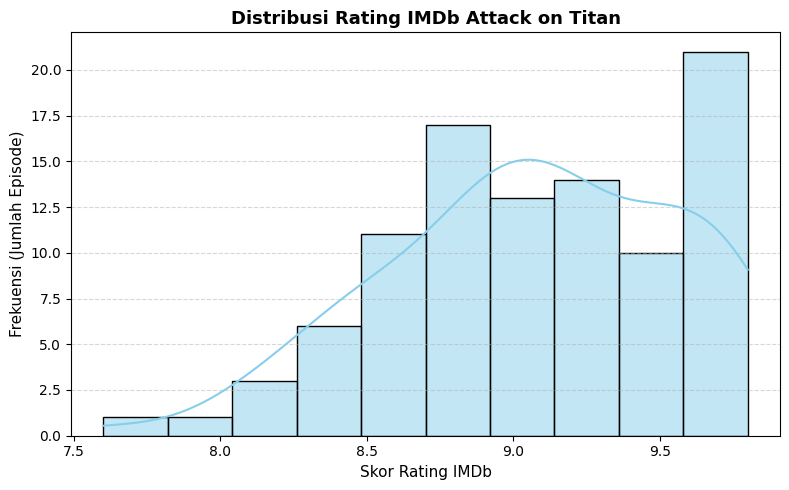

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating IMDb'], kde=True, color='skyblue', bins=10)

plt.title('Distribusi Rating IMDb Attack on Titan', fontsize=13, fontweight='bold')
plt.xlabel('Skor Rating IMDb', fontsize=11)
plt.ylabel('Frekuensi (Jumlah Episode)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

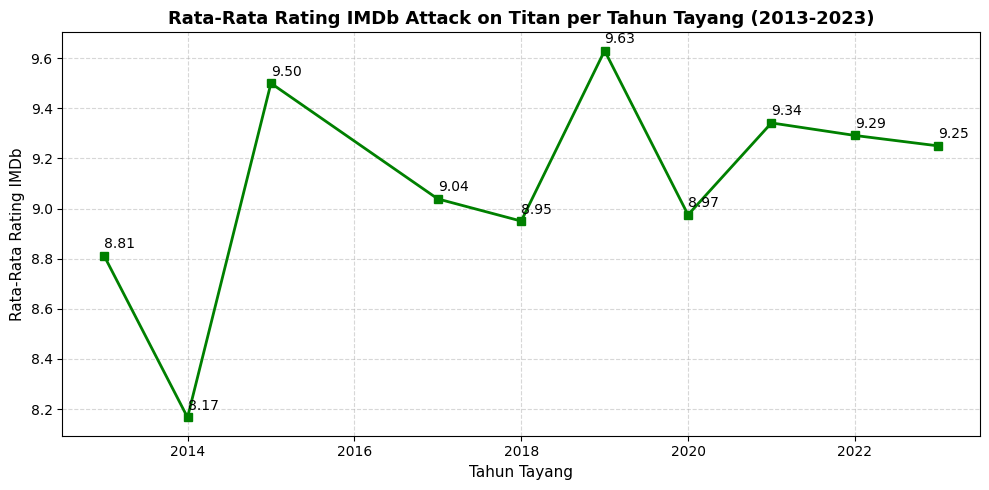

In [8]:
yearly_rating = df.groupby('Tahun Tayang')['Rating IMDb'].agg(['count', 'mean']).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_rating['Tahun Tayang'], yearly_rating['mean'], marker='s', color='green', linewidth=2)

plt.title('Rata-Rata Rating IMDb Attack on Titan per Tahun Tayang (2013-2023)', fontsize=13, fontweight='bold')
plt.xlabel('Tahun Tayang', fontsize=11)
plt.ylabel('Rata-Rata Rating IMDb', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Menampilkan nilai di atas titik
for i, txt in enumerate(yearly_rating['mean']):
    plt.annotate(f"{txt:.2f}", (yearly_rating['Tahun Tayang'][i], yearly_rating['mean'][i]+0.03))

plt.tight_layout()
plt.show()

In [9]:
print("=== TOP 5 EPISODE RATING TERTINGGI ===")
display(df[['No.', 'Season', 'Episode', 'Judul Episode', 'Rating IMDb']].sort_values(by='Rating IMDb', ascending=False).head(5))

print("\n=== TOP 5 EPISODE RATING TERENDAH ===")
display(df[['No.', 'Season', 'Episode', 'Judul Episode', 'Rating IMDb']].sort_values(by='Rating IMDb', ascending=True).head(5))

=== TOP 5 EPISODE RATING TERTINGGI ===


,No.,Season,Episode,Judul Episode,Rating IMDb
35,36,Season 2,Episode 6,Warrior,9.8
71,72,Final Season,Episode 5,Declaration of War,9.8
72,73,Final Season,Episode 6,The War Hammer Titan,9.8
73,74,Final Season,Episode 7,Assault,9.8
60,61,Season 3,Episode 17,Hero,9.8



=== TOP 5 EPISODE RATING TERENDAH ===


,No.,Season,Episode,Judul Episode,Rating IMDb
26,27,OVA,OVA 2,A Sudden Visitor: The Torturous Curse of Adole...,7.6
27,28,OVA,OVA 3,Distress,8.0
2,3,Season 1,Episode 3,"A Dim Light Amid Despair: Humanity's Comeback,...",8.1
14,15,Season 1,Episode 15,Special Operations Squad: Eve of the Counterat...,8.1
15,16,Season 1,Episode 16,What Needs to Be Done Now: Eve of the Countera...,8.2
